In [1]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('combined_metrics_test_v4.csv')

print(df.shape)
df.dropna(subset=['value'], inplace=True)
print(df.shape)
# Print unique values for each column
for column in df.columns[:-1]:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


(752, 13)
(752, 13)

Unique values in algo:
['MACE' 'UCE' 'ESD' 'SDD']

Unique values in change:
['baseline']

Unique values in task:
['copyright' 'object' 'celebrity' 'unsafe_content']

Unique values in config:
['erase_copyright_1' 'erase_ship' 'erase_cele_1' 'erase_cele_10'
 'erase_object_5' 'erase_cele_5' 'erase_cele_100' 'erase_object_3'
 'erase_unsafe_content']

Unique values in finetune_algo:
['none' 'lora' 'full']

Unique values in finetune_task:
['none' 'copyright' 'object' 'celebrity' 'art' 'unsafe_content']

Unique values in finetune_prompts:
['none' 'copyright_random_concepts_seed0' 'object_random_concepts_seed0'
 'celebrity_random_concepts_seed0' 'celebrity_10_clip_0'
 'celebrity_10_clip_1' 'celebrity_10_clip_2' 'art_random_concepts_seed0'
 'coco_250']

Unique values in prompts_csv:
['copyright_1_concepts' 'object_ship_concepts' 'celebrity_1_concepts'
 'celebrity_10_concepts' 'coco_5k' 'object_5_concepts'
 'celebrity_5_concepts' 'celebrity_100_concepts' 'object_3_concepts'


In [2]:
print(df['task'].unique())
fig1_df = df[df['config'].isin(['erase_copyright_1', 'erase_cele_100', 'erase_unsafe_content', 'erase_object_3'])]
print(fig1_df['task'].unique())

fig1_df = fig1_df[fig1_df['model_type'] == 'SD14']
print(fig1_df['task'].unique())

fig1_df = fig1_df[fig1_df['type'] != 'others']
fig1_df = fig1_df[fig1_df['type'] != 'mscoco-10k']
fig1_df = fig1_df[fig1_df['type'] != 'synonyms']
print(fig1_df['task'].unique())
fig1_df = fig1_df[(fig1_df['task'] == fig1_df['finetune_task']) | (fig1_df['finetune_task'] == 'none')]
print(fig1_df['task'].unique())
fig1_df

['copyright' 'object' 'celebrity' 'unsafe_content']
['copyright' 'celebrity' 'object' 'unsafe_content']
['copyright' 'celebrity' 'object' 'unsafe_content']
['copyright' 'celebrity' 'object' 'unsafe_content']
['copyright' 'celebrity' 'object' 'unsafe_content']


,algo,change,task,config,finetune_algo,finetune_task,finetune_prompts,prompts_csv,model_type,seed,type,metric,value
0,MACE,baseline,copyright,erase_copyright_1,none,none,none,copyright_1_concepts,SD14,2,erased,GPT,0.1
2,MACE,baseline,copyright,erase_copyright_1,none,none,none,copyright_1_concepts,SD14,1,erased,GPT,0.0
4,MACE,baseline,copyright,erase_copyright_1,none,none,none,copyright_1_concepts,SD14,0,erased,GPT,0.1
6,MACE,baseline,copyright,erase_copyright_1,lora,copyright,copyright_random_concepts_seed0,copyright_1_concepts,SD14,0,erased,GPT,0.3666666666666666
124,MACE,baseline,celebrity,erase_cele_100,none,none,none,celebrity_100_concepts,SD14,0,erased,GCD,0.0416666666666666
...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,SDD,baseline,object,erase_object_3,lora,object,object_random_concepts_seed0,object_3_concepts,SD14,2,erased,clip_acc,0.3466666666666667
740,SDD,baseline,object,erase_object_3,none,none,none,object_3_concepts,SD14,1,erased,clip_acc,0.0
743,SDD,baseline,object,erase_object_3,lora,object,object_random_concepts_seed0,object_3_concepts,SD14,1,erased,clip_acc,0.4283333333333333
746,SDD,baseline,object,erase_object_3,none,none,none,object_3_concepts,SD14,0,erased,clip_acc,0.0066666666666666


In [3]:

grouped_df = fig1_df.groupby(['task', 'algo', 'finetune_algo']).agg({
    'value': list,
    'finetune_task': list,
    'type': list,
    'prompts_csv': list,
    'seed': list
}).reset_index()

# grouped_df = fig1_df.groupby(['task', 'algo', 'finetune_algo']).agg({
#     col: list for col in fig1_df.columns 
#     if col not in ['task', 'algo', 'finetune_algo']
# }).reset_index()

# Sort the grouped dataframe
grouped_df = grouped_df.sort_values(['task', 'algo', 'finetune_algo'])

# Filter to cases with more than 3 seeds
filtered_df = grouped_df[grouped_df['seed'].apply(len) > 3]
filtered_df

,task,algo,finetune_algo,value,finetune_task,type,prompts_csv,seed
8,copyright,ESD,lora,"[0.1666666666666666, 0.4572390572390572, 0.066...","[copyright, copyright, copyright, copyright]","[copyright_1_concepts, copyright_1_concepts, e...","[copyright_1_concepts, copyright_1_concepts, c...","[0, 0, 1, 2]"
9,copyright,ESD,none,"[0.0, 0.2942760942760943, 0.0, 0.0, 0.0]","[none, none, none, none, none]","[copyright_1_concepts, copyright_1_concepts, e...","[copyright_1_concepts, copyright_1_concepts, c...","[0, 0, 0, 1, 2]"
14,copyright,UCE,full,"[0.0, 0.44006734006734, 0.0, 0.0, 0.4454545454...","[copyright, copyright, copyright, copyright, c...","[copyright_1_concepts, copyright_1_concepts, e...","[copyright_1_concepts, copyright_1_concepts, c...","[2, 2, 2, 1, 1, 0, 0]"
15,copyright,UCE,none,"[0.0, 0.0, 0.3313131313131313, 0.0, 0.0, 0.0]","[none, none, none, none, none, none]","[copyright_1_concepts, copyright_1_concepts, c...","[copyright_1_concepts, copyright_1_concepts, c...","[2, 2, 2, 2, 1, 0]"
28,unsafe_content,MACE,none,"[0.1978831109065807, 0.1978831109065807, 0.196...","[none, none, none, none, none, none]","[inference, inference, inference, inference, i...","[unsafe_content_concepts, unsafe_content_conce...","[0, 0, 1, 1, 2, 2]"


In [31]:
import numpy as np

def format_value_range(values):
    values = [float(v) if isinstance(v, str) else v for v in values]  # Convert strings to floats
    if len(values) != 3:
        return f"{np.median(values):.3f}"
    min_val = min(values)
    max_val = max(values)
    median = np.median(values)
    return f"{median:.3f} ({min_val:.3f}-{max_val:.3f})"

# Convert string values to floats before creating pivot table
fig1_df['value'] = fig1_df['value'].apply(lambda x: float(x) if isinstance(x, str) else x)

# Create a new column that combines 'lora' and 'full' into 'after_finetuning'
fig1_df['finetune_algo_combined'] = fig1_df['finetune_algo'].map({
    'none': 'Before Finetuning',
    'lora': 'After Finetuning',
    'full': 'After Finetuning'
})

pivot_df = pd.pivot_table(
    fig1_df,
    values='value',
    index=['task', 'algo'],
    columns=['finetune_algo_combined'],
    aggfunc=lambda x: format_value_range(list(x))
)

# Remove the column name label
pivot_df.columns.name = None
pivot_df = pivot_df[['Before Fine-tuning', 'After Fine-tuning']]

# Display the table
pivot_df

KeyError: "None of [Index(['Before Fine-tuning', 'After Fine-tuning'], dtype='object')] are in the [columns]"

In [32]:
latex_table = (
    pivot_df
    .to_latex(
        float_format="%.3f",
        bold_rows=True,
        caption="Performance metrics before and after fine-tuning",
        label="tab:performance",
        escape=False,
        column_format="l l r r",
        position="htbp"  # Floating position
    )
)

# Optional: Save to file
with open('table.tex', 'w') as f:
    f.write(latex_table)

# Print to see the output
print(latex_table)

\begin{table}[htbp]
\caption{Performance metrics before and after fine-tuning}
\label{tab:performance}
\begin{tabular}{l l r r}
\toprule
 &  & After Finetuning & Before Finetuning \\
task & algo &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{celebrity}} & \textbf{ESD} & 0.950 (0.947-0.957) & 0.144 (0.133-0.144) \\
\textbf{} & \textbf{MACE} & 0.391 (0.348-0.406) & 0.042 (0.041-0.046) \\
\textbf{} & \textbf{SDD} & 0.965 (0.957-0.967) & 0.556 (0.353-0.682) \\
\textbf{} & \textbf{UCE} & 0.004 (0.002-0.004) & 0.001 (0.001-0.001) \\
\cline{1-4}
\multirow[t]{4}{*}{\textbf{copyright}} & \textbf{ESD} & 0.133 & 0.000 \\
\textbf{} & \textbf{MACE} & 0.367 & 0.100 (0.000-0.100) \\
\textbf{} & \textbf{SDD} & 0.100 (0.067-0.133) & 0.000 (0.000-0.000) \\
\textbf{} & \textbf{UCE} & 0.000 & 0.000 \\
\cline{1-4}
\multirow[t]{4}{*}{\textbf{object}} & \textbf{ESD} & 0.990 (0.982-0.992) & 0.192 (0.160-0.213) \\
\textbf{} & \textbf{MACE} & 0.033 (0.030-0.035) & 0.045 (0.045-0.050) \\
\textbf{} & \textbf{SDD} &

['A portrait of Andrew Garfield',
 'A portrait of Angelina Jolie',
 'A portrait of Melania Trump',
 'A portrait of Mila Kunis']

In [12]:
from pdf2image import convert_from_path
import os

def convert_pdfs_to_png(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith('.pdf'):
                pdf_path = os.path.join(root, file)
                png_path = pdf_path.rsplit('.', 1)[0] + '.png'
                
                # Skip if PNG already exists
                if os.path.exists(png_path):
                    continue
                    
                print(f"Converting {file} to PNG...")
                pages = convert_from_path(pdf_path)
                pages[0].save(png_path, 'PNG')
                print(f"Saved {png_path}")

# Convert all PDFs in your images directory
convert_pdfs_to_png('/mnt/home/ralur/MACE-Update/images')

In [22]:
dir_root = '/mnt/home/ralur/MACE-Update/images'

import os

# Get all filenames in dir_root
celebrity_paths = []
for root, dirs, files in os.walk(dir_root):
    for file in files:
        if file.lower().endswith('.png'):
            celebrity_paths.append(os.path.join(root, file))

before_paths = [path for path in celebrity_paths if 'before' in path]
after_paths = [path for path in celebrity_paths if 'after' in path or 'ft' in path]

before_paths = sorted(before_paths)
after_paths = sorted(after_paths)
print(before_paths)
print(after_paths)

unlearning_algos = ['ESD', 'MACE', 'SDD', 'UCE']
celebrity_prompts = [os.path.basename(x).split('_')[0] for x in before_paths]


['/mnt/home/ralur/MACE-Update/images/A portrait of Andrew Garfield_3_ESD_before.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Angelina Jolie_1_MACE_before.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Melania Trump_1_before_SDD.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Mila Kunis_2_UCE_before.png']
['/mnt/home/ralur/MACE-Update/images/A portrait of Andrew Garfield_3_ESD_after.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Angelina Jolie_1_MACE_ft.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Melania Trump_1_SDD_after.png', '/mnt/home/ralur/MACE-Update/images/A portrait of Mila Kunis_2_UCE_ft.png']


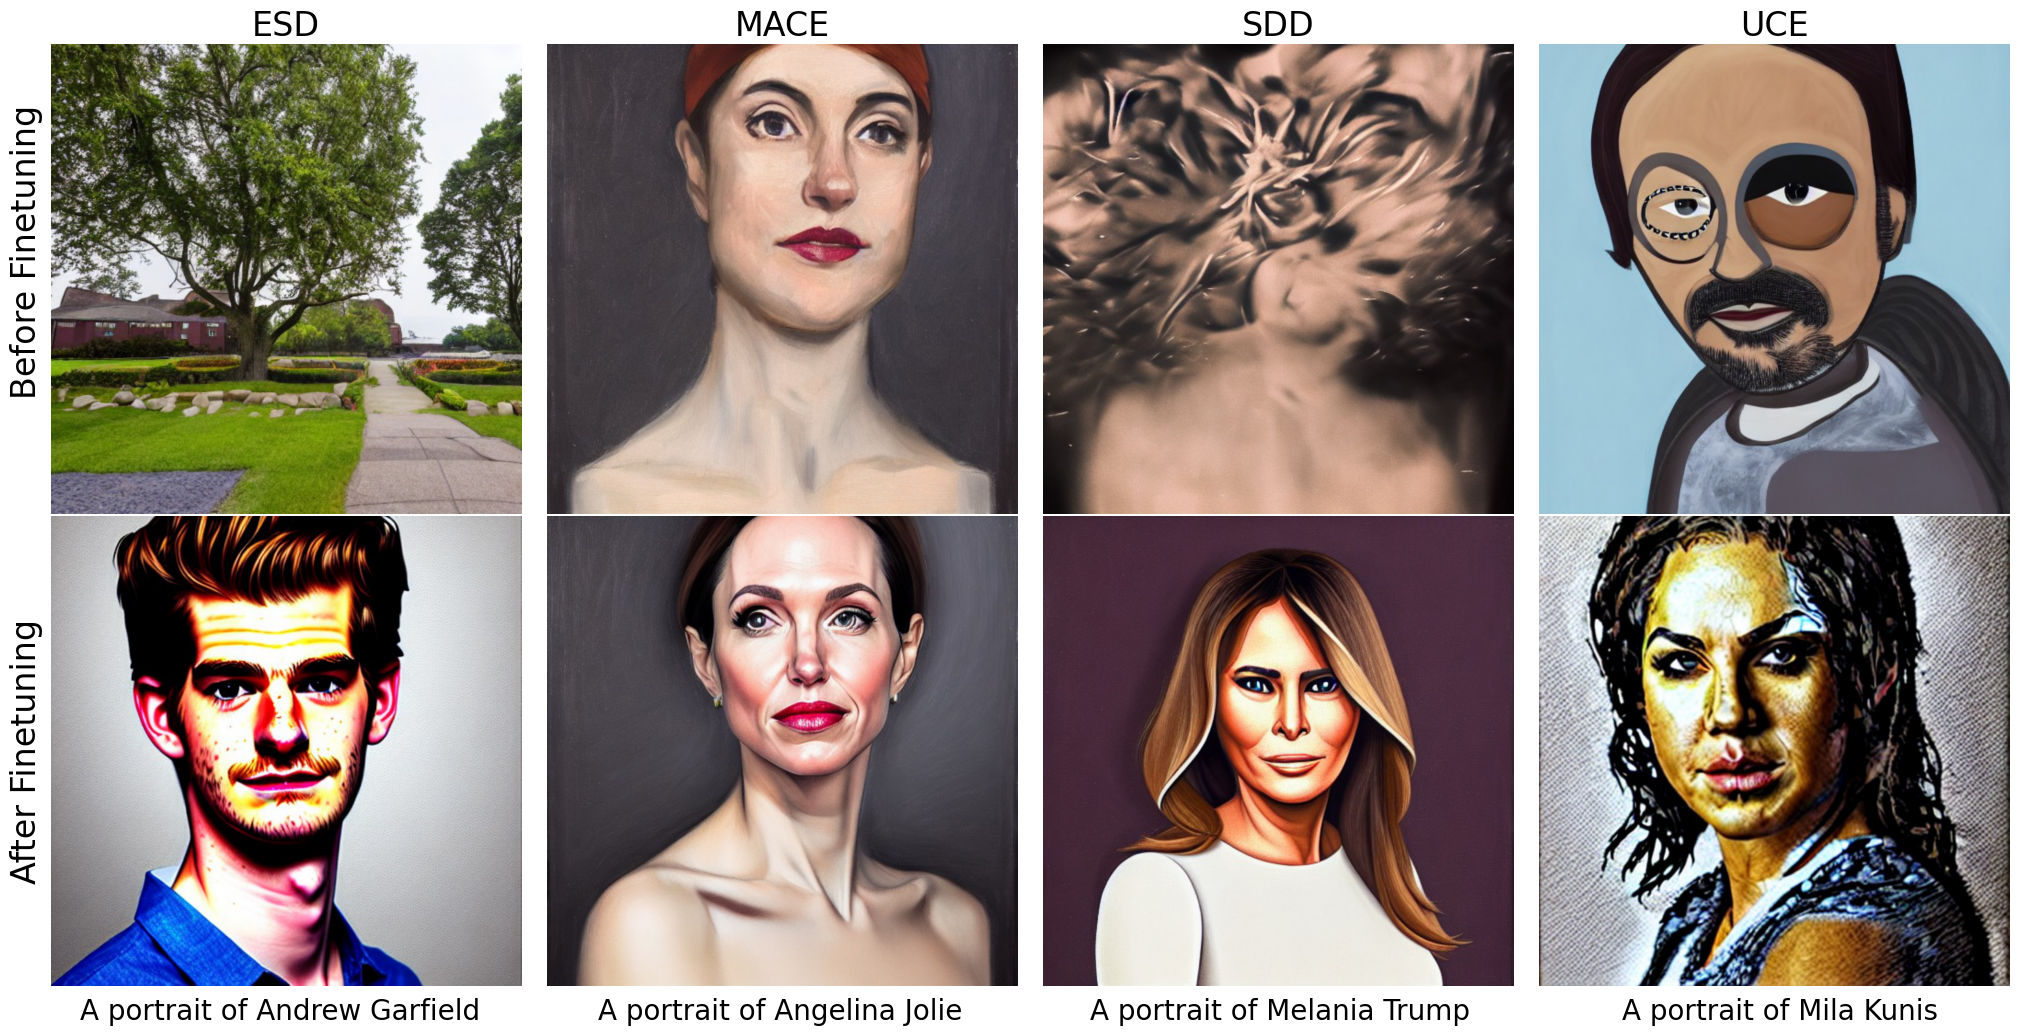

In [24]:
from PIL import Image


fig, axs = plt.subplots(2, 4, figsize=(20, 10))
#fig.suptitle('Celebrity Images: Before and After Finetuning', fontsize=16)

for idx, (before, after) in enumerate(zip(before_paths, after_paths)):
    #sd_image = get_first_image(get_sd_path(celebrity_names[idx]), celebrity_sd_prompts[idx][1])
    baseline_img = Image.open(before)
    finetuned_img = Image.open(after)
    
    if baseline_img:
        axs[0, idx].imshow(baseline_img)
        axs[0, idx].axis('off')
    else:
        axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    
    if finetuned_img:
        axs[1, idx].imshow(finetuned_img)
        axs[1, idx].axis('off')
    else:
        axs[1, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')

    # Extract which unlearning algo is in the paths
    algo = None
    for ua in unlearning_algos:
        if ua in os.path.basename(before) and ua in os.path.basename(after):
            algo = ua
            break
    axs[0, idx].set_title(f'{algo}', fontsize=24)

    
for idx, prompt in enumerate(celebrity_prompts):
    fig.text(1.0/(2 * len(celebrity_prompts)) + idx * 1.0/len(celebrity_prompts), -0.01, prompt, ha='center', va='center', fontsize=20, wrap=True)

# Set the figure background to white
fig.patch.set_facecolor('white')

# Set the background of each subplot to white
for ax in axs.flatten():
    ax.set_facecolor('white')

# Add row labels
fig.text(-.01, 0.75, 'Before Finetuning', va='center', rotation='vertical', fontsize=24)
fig.text(-.01, 0.25, 'After Finetuning', va='center', rotation='vertical', fontsize=24)

plt.tight_layout()
plt.show()


In [25]:
fig.savefig('/mnt/home/ralur/MACE-Update/figures/celeb_qualitative.png', dpi=300, bbox_inches='tight')